# 05 – Machine learning

Use the same forecast target and test period as the econometric models, but add market-based predictors and nonlinear models.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

## Build daily features

In [2]:
rv = pd.read_csv(
    "../data/spy_daily_realized_volatility.csv",
    parse_dates=["date"],
)

raw = pd.read_csv("../data/raw/spy_5min_2024-10-03_2026-09-30.csv")
raw["datetime"] = pd.to_datetime(
    raw["datetime"], utc=True
).dt.tz_convert("America/New_York")

regular = raw[
    (raw["datetime"].dt.time >= pd.to_datetime("09:30").time())
    & (raw["datetime"].dt.time < pd.to_datetime("16:00").time())
].copy()

regular["date"] = pd.to_datetime(regular["datetime"].dt.date)

daily_features = (
    regular.groupby("date")
    .agg(
        open_price=("o", "first"),
        high_price=("h", "max"),
        low_price=("l", "min"),
        close_price=("c", "last"),
        volume=("v", "sum"),
    )
    .reset_index()
)

daily_features["return"] = np.log(
    daily_features["close_price"] / daily_features["open_price"]
)
daily_features["abs_return"] = daily_features["return"].abs()
daily_features["negative_return"] = (daily_features["return"] < 0).astype(int)
daily_features["high_low_range"] = np.log(
    daily_features["high_price"] / daily_features["low_price"]
)
daily_features["log_volume"] = np.log(daily_features["volume"])

df = rv.merge(daily_features, on="date", how="left")

In [3]:
df["rv_daily"] = df["log_realized_variance"]
df["rv_weekly"] = df["log_realized_variance"].rolling(5).mean()
df["rv_monthly"] = df["log_realized_variance"].rolling(22).mean()

df["abs_return_5d"] = df["abs_return"].rolling(5).mean()
df["high_low_range_5d"] = df["high_low_range"].rolling(5).mean()
df["log_volume_5d"] = df["log_volume"].rolling(5).mean()

df["target"] = df["log_realized_variance"].shift(-1)
df["target_date"] = df["date"].shift(-1)

features = [
    "rv_daily",
    "rv_weekly",
    "rv_monthly",
    "return",
    "abs_return",
    "negative_return",
    "high_low_range",
    "log_volume",
    "abs_return_5d",
    "high_low_range_5d",
    "log_volume_5d",
]

ml_data = df[["date", "target_date", "target"] + features].dropna().copy()
ml_data.head()

,date,target_date,target,rv_daily,rv_weekly,rv_monthly,return,abs_return,negative_return,high_low_range,log_volume,abs_return_5d,high_low_range_5d,log_volume_5d
21,2024-11-04,2024-11-05,-10.397592,-10.317511,-10.251208,-10.691808,-0.002472,0.002472,1,0.008085,17.220172,0.004142,0.008780,17.370455
22,2024-11-05,2024-11-06,-10.270716,-10.397592,-10.226694,-10.714495,0.010354,0.010354,0,0.010791,17.363313,0.005576,0.009396,17.374193
23,2024-11-06,2024-11-07,-11.139952,-10.270716,-10.135939,-10.695987,0.003118,0.003118,0,0.011110,17.823583,0.005745,0.010232,17.482102
24,2024-11-07,2024-11-08,-11.595449,-11.139952,-10.410438,-10.701170,0.004156,0.004156,0,0.006136,17.470898,0.004125,0.008945,17.451200
25,2024-11-08,2024-11-11,-11.377216,-11.595449,-10.744244,-10.722783,0.003466,0.003466,0,0.005812,17.433420,0.004713,0.008387,17.462277


## Use the same test period as HAR-RV

In [4]:
har_forecasts = pd.read_csv(
    "../results/har_rv_forecasts.csv",
    parse_dates=["target_date"],
)

test_dates = har_forecasts["target_date"]
first_test_date = test_dates.min()

train = ml_data[ml_data["target_date"] < first_test_date].copy()
test = ml_data[ml_data["target_date"].isin(test_dates)].copy()

X_train, y_train = train[features], train["target"]
X_test, y_test = test[features], test["target"]

test["actual_rv"] = np.exp(test["target"])

print("Training observations:", len(train))
print("Test observations:", len(test))
print("Same test dates:", set(test["target_date"]) == set(test_dates))

Training observations: 376
Test observations: 95
Same test dates: True


In [5]:
def qlike_loss(actual, forecast):
    ratio = actual / forecast
    return ratio - np.log(ratio) - 1


def evaluate_predictions(pred):
    rv_forecast = np.exp(pred)

    return (
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        qlike_loss(test["actual_rv"], rv_forecast).mean(),
        rv_forecast,
    )


tscv = TimeSeriesSplit(n_splits=5)

## Elastic Net

In [6]:
elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000)),
])

elastic_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
}

elastic_search = GridSearchCV(
    elastic,
    elastic_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
)

elastic_search.fit(X_train, y_train)
elastic_search.best_params_

{'model__alpha': 1.0, 'model__l1_ratio': 0.0}

In [7]:
elastic_pred = elastic_search.predict(X_test)
elastic_mae, elastic_rmse, elastic_qlike, elastic_rv = evaluate_predictions(elastic_pred)

test["elastic_net_prediction"] = elastic_pred
test["elastic_rv_forecast"] = elastic_rv

print(f"MAE: {elastic_mae:.4f}")
print(f"RMSE: {elastic_rmse:.4f}")
print(f"QLIKE: {elastic_qlike:.4f}")

MAE: 0.5177
RMSE: 0.6448
QLIKE: 0.2462


Cross-validation selected `l1_ratio = 0`, so the best Elastic Net specification is effectively Ridge regression in this sample.

## Random Forest

In [8]:
rf = RandomForestRegressor(random_state=42)

rf_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

rf_search = GridSearchCV(
    rf,
    rf_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

rf_search.best_params_

{'max_depth': 3,
 'max_features': 0.5,
 'min_samples_leaf': 5,
 'n_estimators': 500}

In [9]:
rf_pred = rf_search.predict(X_test)
rf_mae, rf_rmse, rf_qlike, rf_rv = evaluate_predictions(rf_pred)

test["rf_prediction"] = rf_pred
test["rf_rv_forecast"] = rf_rv

print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"QLIKE: {rf_qlike:.4f}")

MAE: 0.5305
RMSE: 0.6669
QLIKE: 0.2462


## XGBoost

In [10]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

xgb_search = GridSearchCV(
    xgb,
    xgb_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

xgb_search.fit(X_train, y_train)
xgb_search.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.01,
 'max_depth': 2,
 'n_estimators': 300,
 'subsample': 0.7}

In [11]:
xgb_pred = xgb_search.predict(X_test)
xgb_mae, xgb_rmse, xgb_qlike, xgb_rv = evaluate_predictions(xgb_pred)

test["xgb_prediction"] = xgb_pred
test["xgb_rv_forecast"] = xgb_rv

print(f"MAE: {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"QLIKE: {xgb_qlike:.4f}")

MAE: 0.5260
RMSE: 0.6619
QLIKE: 0.2455


## XGBoost interpretation

In [12]:
xgb_best = xgb_search.best_estimator_

feature_importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": xgb_best.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

feature_importance

,Feature,Importance
9,high_low_range_5d,0.291012
0,rv_daily,0.170573
8,abs_return_5d,0.125522
1,rv_weekly,0.100745
6,high_low_range,0.077716
3,return,0.061706
4,abs_return,0.053129
2,rv_monthly,0.043959
7,log_volume,0.041681
10,log_volume_5d,0.033958


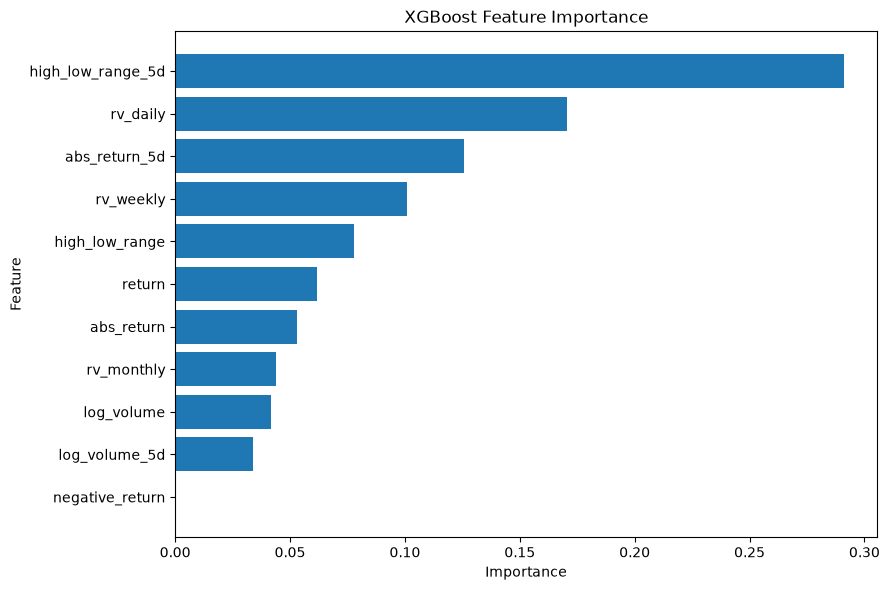

In [13]:
plt.figure(figsize=(9, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

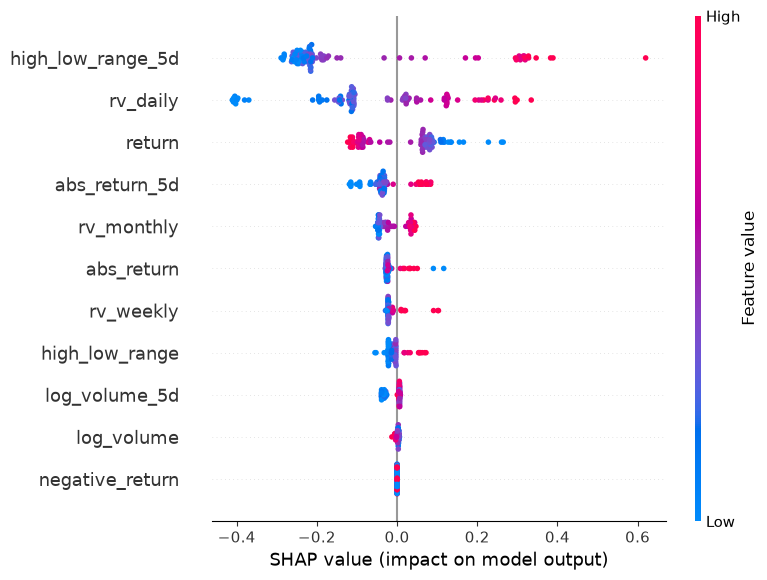

In [14]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)

## Save results

In [15]:
ml_results = pd.DataFrame({
    "Model": ["Elastic Net", "Random Forest", "XGBoost"],
    "MAE": [elastic_mae, rf_mae, xgb_mae],
    "RMSE": [elastic_rmse, rf_rmse, xgb_rmse],
    "QLIKE": [elastic_qlike, rf_qlike, xgb_qlike],
})

ml_results.to_csv("../results/ml_model_comparison.csv", index=False)

test[[
    "target_date",
    "target",
    "actual_rv",
    "elastic_net_prediction",
    "elastic_rv_forecast",
    "rf_prediction",
    "rf_rv_forecast",
    "xgb_prediction",
    "xgb_rv_forecast",
]].to_csv("../results/ml_forecasts.csv", index=False)

ml_results

,Model,MAE,RMSE,QLIKE
0,Elastic Net,0.517746,0.644805,0.246191
1,Random Forest,0.530517,0.666855,0.246232
2,XGBoost,0.526026,0.661889,0.245484
